In [1]:
from sklearn.datasets import load_iris
import pandas as pd
iris = load_iris()
from sklearn.cluster import KMeans
iris_df = pd.DataFrame(data=iris.data, columns=['sepal_length', 'sepal_width'
                                                , 'petal_length', 'petal_width'])
iris_df.head(3)


,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [5]:
KM=KMeans(n_clusters=3,max_iter=300,random_state=0)
KM.fit(iris_df) # 훈련/ 테스트 분할x
KM.labels_ # 각 데이터가 속한 군집번호

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [7]:
iris_df['target']=iris.target # 실제값
iris_df['cluster']=KM.labels_ # 모델이 정한 군집번호
iris_df.head(3)


,sepal_length,sepal_width,petal_length,petal_width,target,cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1


In [9]:
iris_df.groupby(['target','cluster'])['sepal_length'].count()

target  cluster
0       1          50
1       0          47
        2           3
2       0          14
        2          36
Name: sepal_length, dtype: int64

군집의 평가: 실루엣 계수

In [15]:
from sklearn.metrics import silhouette_score,silhouette_samples
iris_df['silhouette_coeff']=silhouette_samples(iris.data,iris_df['cluster'])
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,silhouette_coeff
0,5.1,3.5,1.4,0.2,0,1,0.852582
1,4.9,3.0,1.4,0.2,0,1,0.814916
2,4.7,3.2,1.3,0.2,0,1,0.828797
3,4.6,3.1,1.5,0.2,0,1,0.804352
4,5.0,3.6,1.4,0.2,0,1,0.848918


In [17]:
score_sample=silhouette_samples(iris.data,iris_df['cluster'])
score_sample 

array([ 0.85258191,  0.8149163 ,  0.82879659,  0.80435199,  0.84891774,
        0.7477614 ,  0.82109757,  0.8534934 ,  0.75127806,  0.82475199,
        0.80269525,  0.83540396,  0.80996716,  0.74535637,  0.70224038,
        0.64338856,  0.77526857,  0.85063272,  0.70636742,  0.81987458,
        0.78364122,  0.82546665,  0.79244412,  0.79345251,  0.77426479,
        0.79799564,  0.83296108,  0.84162136,  0.84325046,  0.81723402,
        0.8145665 ,  0.79849826,  0.76227879,  0.72184605,  0.82822866,
        0.83179477,  0.79374024,  0.84148042,  0.76779363,  0.84992603,
        0.84902387,  0.63767419,  0.78589195,  0.79963167,  0.74629437,
        0.80915172,  0.81295565,  0.81844011,  0.81783314,  0.85168255,
       -0.02672203,  0.36827154,  0.08489767,  0.59610609,  0.35669884,
        0.59416206,  0.27019063,  0.27245453,  0.32755642,  0.58167084,
        0.38107057,  0.58665651,  0.55085685,  0.47851679,  0.56757079,
        0.30479553,  0.5596951 ,  0.61137194,  0.46029717,  0.61

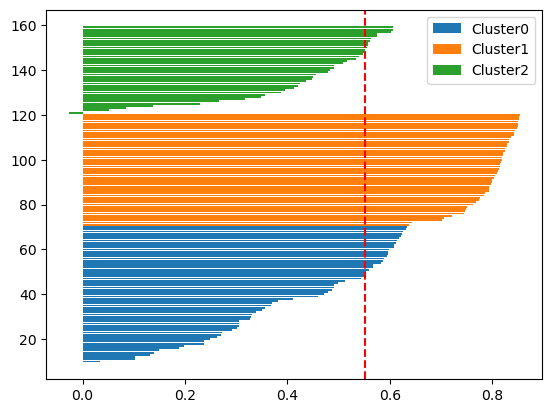

In [25]:
# 실루엣계수 시각화
import matplotlib.pyplot as plt
y_lower=10
for i in range(3):
   cluster_i=score_sample[iris_df['cluster']== i]
   cluster_i.sort()
   y_upper = y_lower + len(cluster_i)
   plt.barh(range(y_lower,y_upper),cluster_i,label=f'Cluster{i}')
   y_lower=y_upper
avg_score=silhouette_score(iris.data,iris_df['cluster'])
plt.axvline(avg_score,color='r',linestyle='--')
plt.legend()
plt.show()    

K의 값을 조정
데이터 스케일링

# k 값의 선택을 위한 스크리차트 

In [30]:
scree_df=iris_df[['sepal_length','sepal_width','petal_length','petal_width']]
sse_values=[]
k_values= range(1,11)
for k in k_values:
  kmeans=KMeans(n_clusters=k,init='k-means++',max_iter=300,random_state=0)
  kmeans.fit(scree_df) 
  sse_values.append(kmeans.inertia_) 

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

In [31]:
sse_values

[681.3706,
 152.34795176035792,
 78.85566582597728,
 57.228473214285714,
 49.82774055829229,
 42.42154575309748,
 34.420191786283894,
 30.064593073593073,
 28.715856536394465,
 27.46211879129643]

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

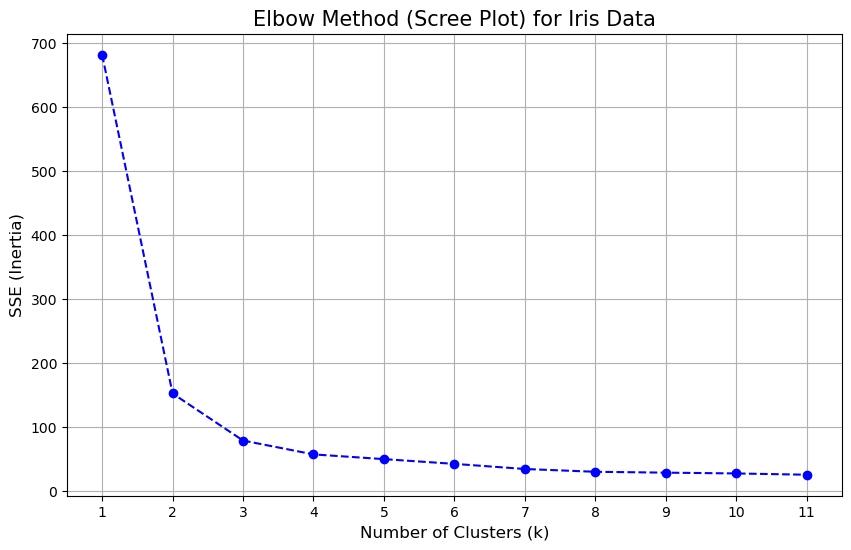

In [32]:
scree_df = iris_df[['sepal_length','sepal_width','petal_length','petal_width']]
sse_values = []
k_values = range(1, 12)  # 1부터 11까지 포함

for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, random_state=0)
    kmeans.fit(scree_df)
    sse_values.append(kmeans.inertia_)

# 2. 시각화 (스크리 차트 그리기)
plt.figure(figsize=(10, 6))
plt.plot(k_values, sse_values, marker='o', linestyle='--', color='b')

# 차트 디테일 설정
plt.title('Elbow Method (Scree Plot) for Iris Data', fontsize=15)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('SSE (Inertia)', fontsize=12)
plt.xticks(k_values) # x축 눈금을 1부터 11까지 명시
plt.grid(True)

plt.show()

# iris_df 차원축소

In [33]:
from sklearn.decomposition import PCA

# PCA 객체 생성 (주성분 2개로 축소)
pca = PCA(n_components=2)

# 데이터 변환
X_pca = pca.fit_transform(iris.data)

# 설명된 분산 비율 확인
print(pca.explained_variance_ratio_)

[0.92461872 0.05306648]


In [34]:
X_pca

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045],
       [-2.82053775, -0.08946138],
       [-2.62614497,  0.16338496],
       [-2.88638273, -0.57831175],
       [-2.6727558 , -0.11377425],
       [-2.50694709,  0.6450689 ],
       [-2.61275523,  0.01472994],
       [-2.78610927, -0.235112  ],
       [-3.22380374, -0.51139459],
       [-2.64475039,  1.17876464],
       [-2.38603903,  1.33806233],
       [-2.62352788,  0.81067951],
       [-2.64829671,  0.31184914],
       [-2.19982032,  0.87283904],
       [-2.5879864 ,  0.51356031],
       [-2.31025622,  0.39134594],
       [-2.54370523,  0.43299606],
       [-3.21593942,  0.13346807],
       [-2.30273318,  0.09870885],
       [-2.35575405, -0.03728186],
       [-2.50666891, -0.14601688],
       [-2.46882007,  0.13095149],
       [-2.56231991,  0.36771886],
       [-2.63953472,

In [35]:
iris_df['pca_x']=X_pca[:,0]
iris_df['pca_y']=X_pca[:,1]
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,silhouette_coeff,pca_x,pca_y
0,5.1,3.5,1.4,0.2,0,1,0.852582,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,0.814916,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,0.828797,-2.888991,-0.144949
3,4.6,3.1,1.5,0.2,0,1,0.804352,-2.745343,-0.318299
4,5.0,3.6,1.4,0.2,0,1,0.848918,-2.728717,0.326755


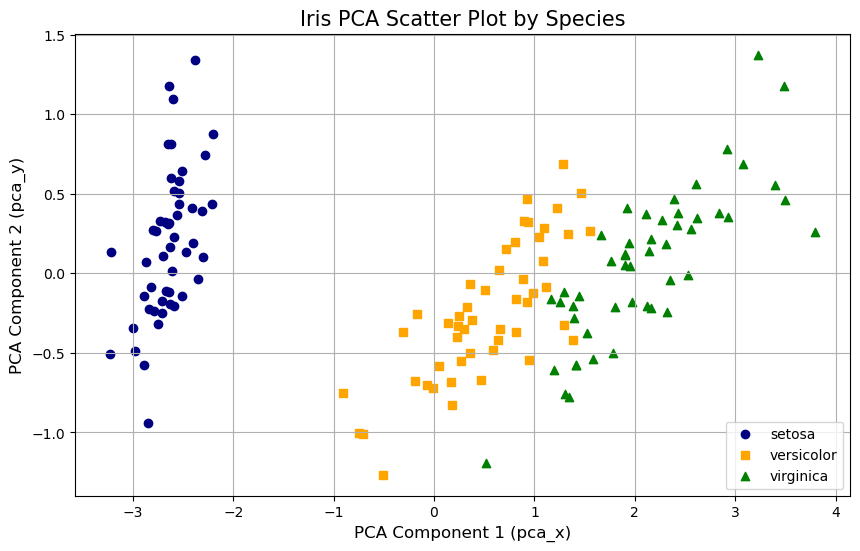

In [36]:
import matplotlib.pyplot as plt

# 1. 실제 품종(target)별로 다른 마커와 색상으로 시각화
plt.figure(figsize=(10, 6))
markers = ['o', 's', '^'] # setosa, versicolor, virginica 순서
colors = ['navy', 'orange', 'green']

for i, marker in enumerate(markers):
    # 각 라벨별로 데이터 필터링
    x_data = iris_df[iris_df['target'] == i]['pca_x']
    y_data = iris_df[iris_df['target'] == i]['pca_y']
    
    plt.scatter(x_data, y_data, marker=marker, color=colors[i], label=iris.target_names[i])

# 차트 꾸미기
plt.title('Iris PCA Scatter Plot by Species', fontsize=15)
plt.xlabel('PCA Component 1 (pca_x)', fontsize=12)
plt.ylabel('PCA Component 2 (pca_y)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

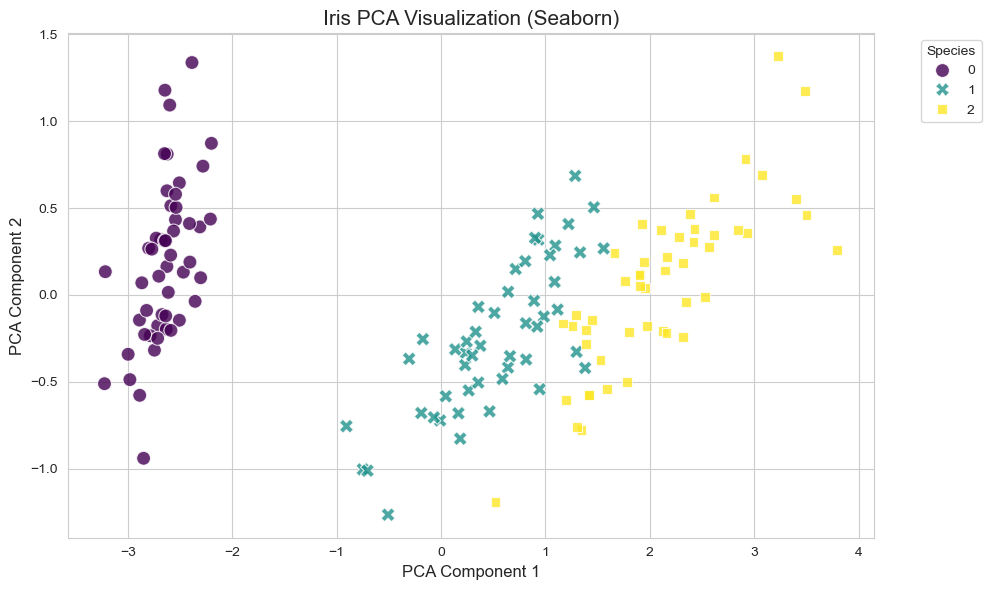

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 시각화를 위해 숫자 라벨(0,1,2)을 실제 품종 이름으로 매핑 (선택 사항)
iris_df['species_name'] = iris_df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# 2. Seaborn 산점도 그리기
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid") # 배경 격자 스타일 설정

scatter = sns.scatterplot(
    data=iris_df, 
    x='pca_x', 
    y='pca_y', 
    hue='target',       # 라벨(품종)별로 색상 구분
    style='target',     # 라벨(품종)별로 마커 모양 구분
    palette='viridis',  # 색상 테마 설정
    s=100,              # 점 크기
    alpha=0.8           # 투명도
)

# 차트 디테일 설정
plt.title('Iris PCA Visualization (Seaborn)', fontsize=15)
plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left') # 범례 위치 조절

plt.tight_layout()
plt.show()

In [40]:
# iris_df 피처를 스케일링
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. 데이터 표준화 (평균 0, 분산 1로 스케일링)
# iris.data를 직접 사용하거나, 앞에서 만든 iris_df의 피처들만 사용합니다.
scaler = StandardScaler()
iris_scaled = scaler.fit_transform(iris.data)

# 2. PCA 객체 생성 (주성분 2개로 축소)
pca = PCA(n_components=2)

# 3. 스케일링된 데이터로 PCA 변환 수행
X_pca = pca.fit_transform(iris_scaled)

# 4. 설명된 분산 비율(Explained Variance Ratio) 확인
print(f"각 주성분이 설명하는 분산 비율: {pca.explained_variance_ratio_}")
print(f"전체 설명 가능한 분산의 합: {pca.explained_variance_ratio_.sum():.4f}")

각 주성분이 설명하는 분산 비율: [0.72962445 0.22850762]
전체 설명 가능한 분산의 합: 0.9581


In [ ]:
# 2개의 주성분 분석

scale 전 :# 2개의 주성분 분석

scale 전 :[0.92461872 0.05306648]
scale 후 :[0.72962445 0.22850762]

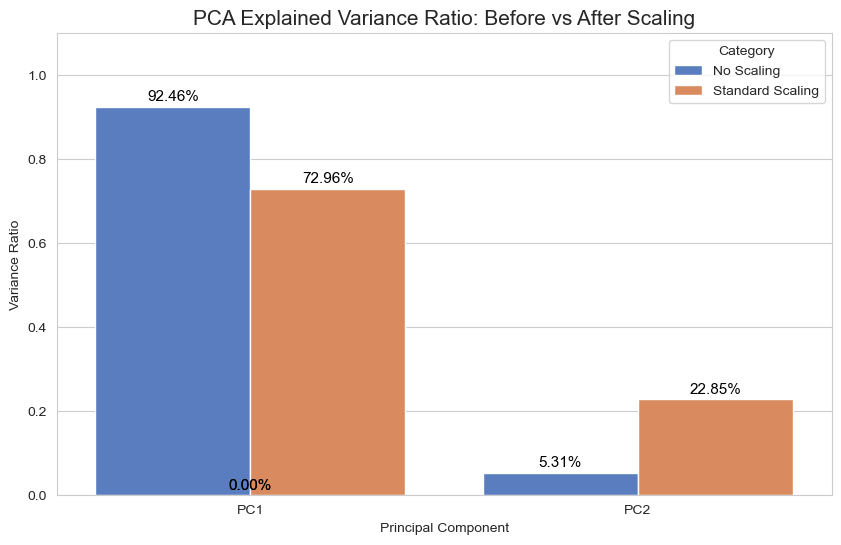

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

# 1. 데이터 준비
iris = load_iris()
X = iris.data

# 2. 스케일링 전 PCA 수행
pca_raw = PCA(n_components=2)
pca_raw.fit(X)
ratio_raw = pca_raw.explained_variance_ratio_

# 3. 스케일링 후 PCA 수행
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca_scaled = PCA(n_components=2)
pca_scaled.fit(X_scaled)
ratio_scaled = pca_scaled.explained_variance_ratio_

# 4. 비교를 위한 데이터프레임 구성
df_compare = pd.DataFrame({
    'Principal Component': ['PC1', 'PC2', 'PC1', 'PC2'],
    'Explained Variance Ratio': [ratio_raw[0], ratio_raw[1], ratio_scaled[0], ratio_scaled[1]],
    'Category': ['No Scaling', 'No Scaling', 'Standard Scaling', 'Standard Scaling']
})

# 5. 시각화 (Seaborn 사용)
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(data=df_compare, x='Principal Component', y='Explained Variance Ratio', hue='Category', palette='muted')

# 막대 위에 퍼센트 수치 표시
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2%}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 7),
                textcoords='offset points')

plt.title('PCA Explained Variance Ratio: Before vs After Scaling', fontsize=15)
plt.ylabel('Variance Ratio')
plt.ylim(0, 1.1) # 수치 표시 공간 확보
plt.show()

--- PCA Loading Values ---
                   PC1       PC2
sepal_length  0.521066  0.377418
sepal_width  -0.269347  0.923296
petal_length  0.580413  0.024492
petal_width   0.564857  0.066942


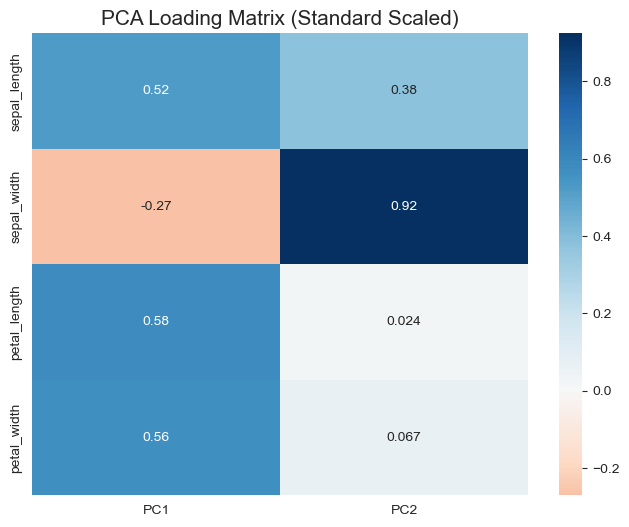

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. 로딩값 계산 (pca.components_ 이용)
# 행: 주성분(PC1, PC2), 열: 원본 피처명
loadings = pd.DataFrame(
    pca_scaled.components_.T, 
    columns=['PC1', 'PC2'], 
    index=features
)

print("--- PCA Loading Values ---")
print(loadings)

# 2. 히트맵으로 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, cmap='RdBu', center=0)
plt.title('PCA Loading Matrix (Standard Scaled)', fontsize=15)
plt.show()